In [11]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
x = np.array([[1],[2],[3],[4]])
y = np.array([2, 4, 6, 8])

In [3]:
lin_reg = LinearRegression()
lin_reg.fit(x, y)
y_pred_lin = lin_reg.predict(x) 
print(lin_reg.coef_)
print(lin_reg.intercept_)
y_pred_lin

[2.]
0.0


array([2., 4., 6., 8.])

In [4]:
# Ridge
lin_ridge = Ridge(alpha=10)
lin_ridge.fit(x, y)
y_pred_ridge = lin_ridge.predict(x)
print(lin_ridge.coef_)
print(lin_ridge.intercept_)
y_pred_ridge

[0.66666667]
3.3333333333333335


array([4.        , 4.66666667, 5.33333333, 6.        ])

In [5]:
# Lasso
lin_lasso = Lasso(alpha=10)
lin_lasso.fit(x, y)
y_pred_lasso = lin_lasso.predict(x)
print(lin_lasso.coef_)
print(lin_lasso.intercept_)
y_pred_lasso

[0.]
5.0


array([5., 5., 5., 5.])

In [6]:
print("linear Regression")
print("mse :", mean_squared_error(y, y_pred_lin))
print("r2_score :", r2_score(y, y_pred_lin))
print("=======================")
print("Ridge Regression")
print("mse :", mean_squared_error(y, y_pred_ridge))
print("r2_score :", r2_score(y, y_pred_ridge))
print("=======================")
print("lasso Regression")
print("mse :", mean_squared_error(y, y_pred_lasso))
print("r2_score :", r2_score(y, y_pred_lasso))
print("=======================")

linear Regression
mse : 0.0
r2_score : 1.0
Ridge Regression
mse : 2.2222222222222223
r2_score : 0.5555555555555556
lasso Regression
mse : 5.0
r2_score : 0.0


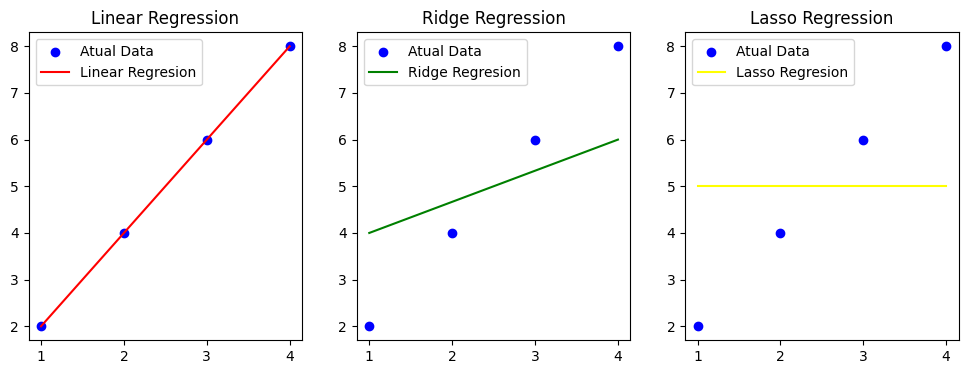

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(x, y, color='blue', label='Atual Data')
plt.plot(x, y_pred_lin, color='red', label='Linear Regresion')
plt.title("Linear Regression")
plt.legend() 

plt.subplot(1, 3, 2)
plt.scatter(x, y, color='blue', label='Atual Data')
plt.plot(x, y_pred_ridge, color='green', label='Ridge Regresion')
plt.title("Ridge Regression")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(x, y, color='blue', label='Atual Data')
plt.plot(x, y_pred_lasso, color='yellow', label='Lasso Regresion')
plt.title("Lasso Regression")
plt.legend()



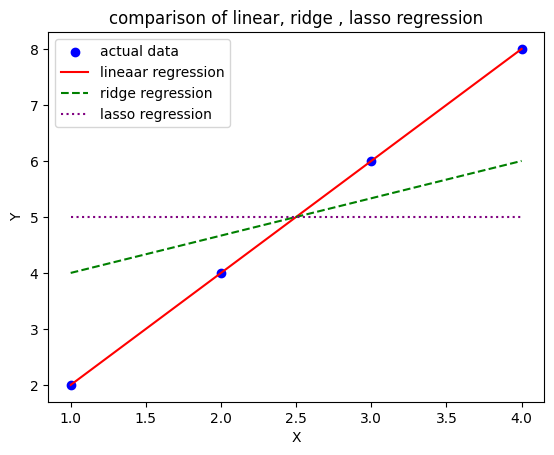

In [8]:
plt.scatter(x,y, color= 'blue', label='actual data')
plt.plot(x,y_pred_lin, color='red', label='lineaar regression')
plt.plot(x,y_pred_ridge, color='green', linestyle="--" , label='ridge regression')
plt.plot(x,y_pred_lasso, color='purple',linestyle=':', label='lasso regression')
plt.title('comparison of linear, ridge , lasso regression')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

In [12]:
data = pd.read_csv('Salary_Data_v2.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Figure size 300x300 with 0 Axes>

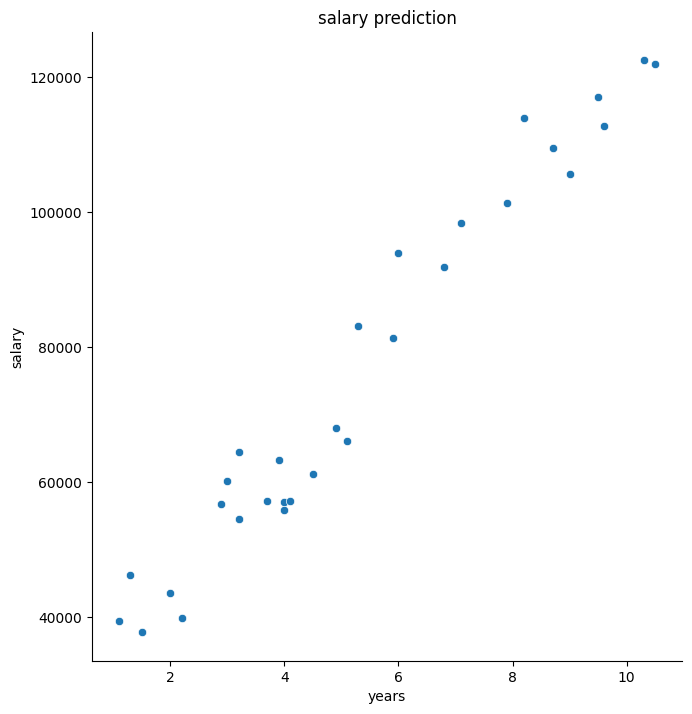

In [13]:
 
plt.figure(figsize=(3,3))
sns.pairplot(data,x_vars=["YearsExperience"],y_vars=["Salary"],size=7,kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary prediction")
plt.show()
 
 

In [16]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=52)

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test  = poly_model.predict(x_poly_test)

In [37]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

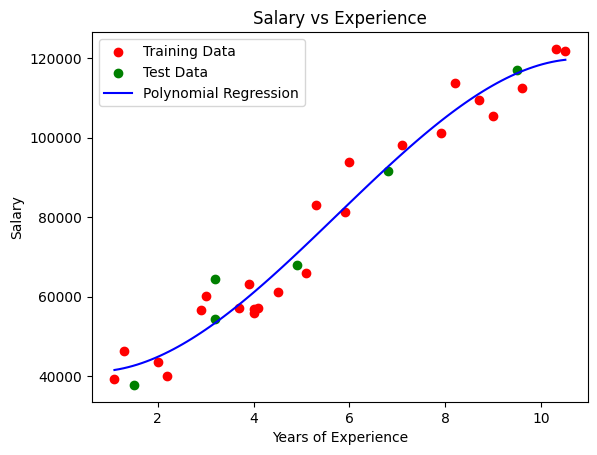

In [38]:
plt.scatter(x_train, y_train, color='red', label='Training Data')
plt.scatter(x_test, y_test, color='green', label='Test Data')
plt.plot(x_range, y_range_pred, color='blue', label='Polynomial Regression')
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import root_mean_squared_error
mse = mean_squared_error(y_test, y_poly_pred_test)
mse
rmse = root_mean_squared_error(y_test, y_poly_pred_test)
rmse

5117.111639135992

In [40]:
r2_score(y_test, y_poly_pred_test)

0.9604025352778552